# Smoothing deep dive — filters, boundaries, and window selection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pypackage_template/blob/main/docs/notebooks/smoothing_deep_dive.ipynb)

Smoothing is a bias/variance trade made explicit: every filter buys a reduction in noise by paying with distortion of the signal. This notebook makes that trade measurable — we generate data with a known latent truth, sweep the filter parameters, and decompose the error into the part caused by leftover noise and the part caused by the filter itself.

**What you'll learn:**

1. Why the moving average, the exponential filter, and the median filter fail in completely different ways.
2. How boundary padding creates artefacts, and how to choose a strategy.
3. How to pick a window length from data rather than by eye.
4. How to read the residual to tell whether you have over-smoothed.

## Background

Model the observations as a latent signal plus independent noise,

$$x_i = f(t_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2).$$

A linear filter with weights $w_k$ produces $y_i = \sum_k w_k x_{i+k}$. Its mean-square error against the truth splits cleanly in two:

$$\mathbb{E}\bigl[(y_i - f(t_i))^2\bigr] = \underbrace{\Bigl(\sum_k w_k f(t_{i+k}) - f(t_i)\Bigr)^2}_{\text{bias}^2 \;(\text{signal distortion})} + \underbrace{\sigma^2 \sum_k w_k^2}_{\text{variance} \;(\text{leftover noise})}.$$

For an equally weighted window of length $w$, $\sum_k w_k^2 = 1/w$: the variance term falls as $1/w$, while the bias term grows with the curvature of $f$ over the window. The optimum is wherever those two curves cross, and that is what we will measure directly.

The median filter is **non-linear**, so this decomposition does not apply to it at all — which is exactly why it behaves so differently at edges and spikes.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "matplotlib",
            "watermark",
            "mypackage @ git+https://github.com/jejjohnson/pypackage_template@main",
        ],
        check=True,
    )

In [2]:
import itertools
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np

import mypackage as mp
from mypackage import Padding

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,matplotlib,mypackage")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy     : 2.4.4
matplotlib: 3.11.0
mypackage : 0.1.6

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## Test signals

Three signals, each designed to break a different filter: a smooth sine (punishes wide windows), a square wave (punishes linear filters at edges), and a flat line with isolated spikes (punishes the mean filter specifically).

In [4]:
rng = np.random.default_rng(seed=0)

n_samples = 300
time = np.linspace(0.0, 1.0, n_samples)
sigma = 0.30

smooth_truth = np.sin(2.0 * np.pi * 2.0 * time)
square_truth = np.sign(np.sin(2.0 * np.pi * 3.0 * time))
spike_truth = np.zeros(n_samples)

spike_observed = spike_truth + rng.normal(0.0, 0.05, n_samples)
spike_observed[[40, 110, 175, 250]] += 6.0

signals = {
    "smooth sine": (
        smooth_truth.tolist(),
        (smooth_truth + rng.normal(0.0, sigma, n_samples)).tolist(),
    ),
    "square wave": (
        square_truth.tolist(),
        (square_truth + rng.normal(0.0, sigma, n_samples)).tolist(),
    ),
    "spikes on flat": (spike_truth.tolist(), spike_observed.tolist()),
}

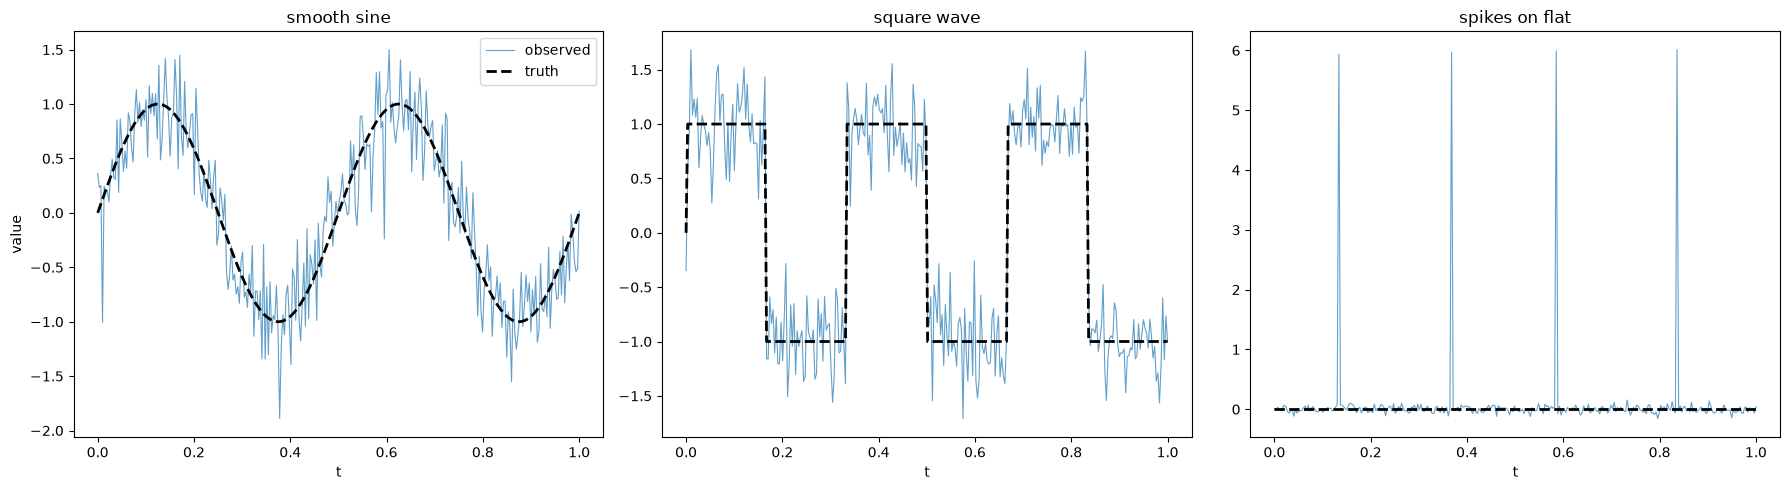

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (truth, observed)) in zip(axes, signals.items(), strict=True):
    ax.plot(time, observed, color="C0", lw=0.8, alpha=0.7, label="observed")
    ax.plot(time, truth, "k--", lw=2.0, label="truth")
    ax.set_xlabel("t")
    ax.set_title(name)
axes[0].set_ylabel("value")
axes[0].legend()
plt.tight_layout()
plt.show()

## Error metric

We score every filter by root-mean-square error against the known truth, computed with `mypackage` itself.

In [6]:
def rmse(estimate: list[float], truth: list[float]) -> float:
    """Root-mean-square error between an estimate and the known truth."""
    squared = [(a - b) ** 2 for a, b in zip(estimate, truth, strict=True)]
    return mp.summarize(squared, ddof=0).mean ** 0.5

## Filter comparison

Same window for the two finite-support filters, and an exponential factor chosen to give a comparable effective memory.

In [7]:
window = 15
alpha = 2.0 / (window + 1.0)  # matches the EWMA "centre of mass" convention

rows: list[tuple[str, float, float, float, float]] = []
for name, (truth, observed) in signals.items():
    rows.append(
        (
            name,
            rmse(observed, truth),
            rmse(mp.moving_average(observed, window), truth),
            rmse(mp.median_filter(observed, window), truth),
            rmse(mp.exponential_moving_average(observed, alpha), truth),
        )
    )

header = f"{'signal':<16}{'raw':>9}{'mean':>9}{'median':>9}{'ewma':>9}"
print(header)
print("-" * len(header))
for name, raw, mean_rmse, median_rmse, ewma_rmse in rows:
    print(f"{name:<16}{raw:>9.4f}{mean_rmse:>9.4f}{median_rmse:>9.4f}{ewma_rmse:>9.4f}")

signal                raw     mean   median     ewma
----------------------------------------------------
smooth sine        0.2926   0.0733   0.0971   0.2058
square wave        0.2780   0.3110   0.1574   0.5078
spikes on flat     0.6921   0.1825   0.0200   0.1810


The ranking flips completely between signals. On the smooth sine the mean filter wins, because averaging is the maximum-likelihood estimator for Gaussian noise around a locally linear signal. On the square wave and the spikes it loses badly — and the median filter, which is worse on the sine, wins by a wide margin.

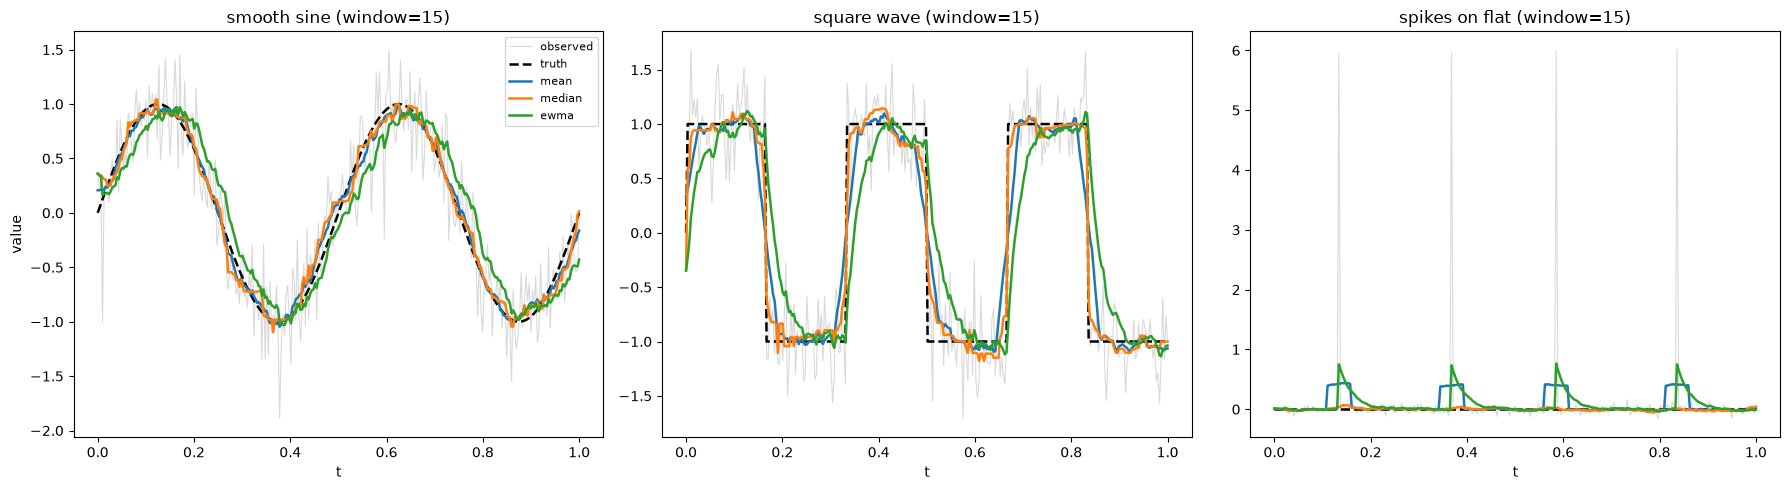

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (truth, observed)) in zip(axes, signals.items(), strict=True):
    ax.plot(time, observed, color="0.85", lw=0.8, label="observed")
    ax.plot(time, truth, "k--", lw=1.8, label="truth")
    ax.plot(time, mp.moving_average(observed, window), color="C0", lw=1.8, label="mean")
    ax.plot(
        time, mp.median_filter(observed, window), color="C1", lw=1.8, label="median"
    )
    ax.plot(
        time,
        mp.exponential_moving_average(observed, alpha),
        color="C2",
        lw=1.8,
        label="ewma",
    )
    ax.set_xlabel("t")
    ax.set_title(f"{name} (window={window})")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Edge preservation

Zooming in on a single transition of the square wave shows the mechanism. The mean filter ramps linearly across the discontinuity over the full window width. The median filter, whose output is an order statistic rather than a weighted sum, keeps the edge sharp until the window is more than half past it.

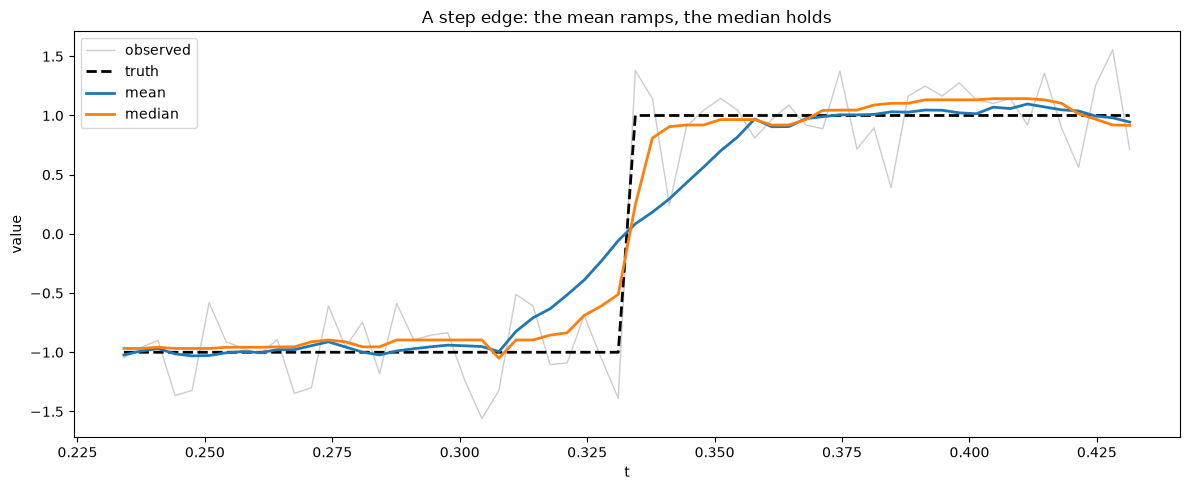

In [9]:
truth, observed = signals["square wave"]
lo, hi = 70, 130

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time[lo:hi], observed[lo:hi], color="0.8", lw=1.0, label="observed")
ax.plot(time[lo:hi], truth[lo:hi], "k--", lw=2.0, label="truth")
mean_zoom = mp.moving_average(observed, window)[lo:hi]
median_zoom = mp.median_filter(observed, window)[lo:hi]
ax.plot(time[lo:hi], mean_zoom, color="C0", lw=2.0, label="mean")
ax.plot(time[lo:hi], median_zoom, color="C1", lw=2.0, label="median")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("A step edge: the mean ramps, the median holds")
ax.legend()
plt.tight_layout()
plt.show()

### Spike rejection

The median has a breakdown point of 50%: up to half the samples in a window can be arbitrarily corrupted without moving the output. The mean has a breakdown point of zero — one sample is enough.

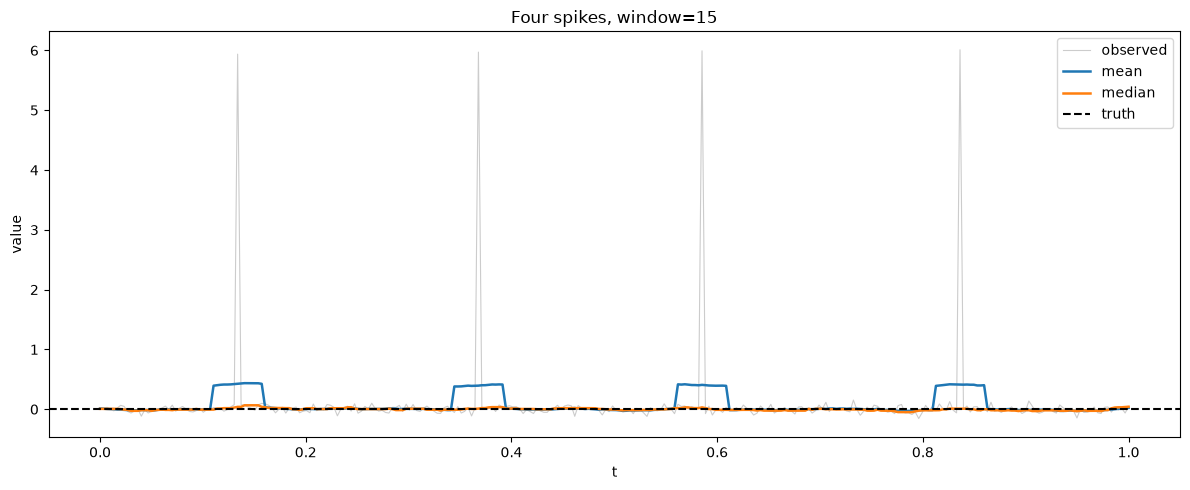

peak |error|, mean filter   : 0.4357
peak |error|, median filter : 0.0658
each spike is smeared over 15 samples by the mean filter


In [10]:
truth, observed = signals["spikes on flat"]
mean_out = mp.moving_average(observed, window)
median_out = mp.median_filter(observed, window)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, observed, color="0.8", lw=0.8, label="observed")
ax.plot(time, mean_out, color="C0", lw=1.8, label="mean")
ax.plot(time, median_out, color="C1", lw=1.8, label="median")
ax.axhline(0.0, color="k", ls="--", lw=1.5, label="truth")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title(f"Four spikes, window={window}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"peak |error|, mean filter   : {max(abs(v) for v in mean_out):.4f}")
print(f"peak |error|, median filter : {max(abs(v) for v in median_out):.4f}")
print(f"each spike is smeared over {window} samples by the mean filter")

## Boundary handling

Finite-support filters need values past the ends of the series, and there is no correct answer — only a choice you should make deliberately. `Padding` makes it explicit.

In [11]:
ramp = [float(index) for index in range(1, 21)]
ramp_window = 7

for strategy in Padding:
    smoothed = mp.moving_average(ramp, ramp_window, padding=strategy)
    head = ", ".join(f"{value:6.2f}" for value in smoothed[:3])
    tail = ", ".join(f"{value:6.2f}" for value in smoothed[-3:])
    print(f"{strategy.value:<9} len={len(smoothed):>3} first: [{head}] last: [{tail}]")

print(
    "\ntruth     len= 20 first: [  1.00,   2.00,   3.00] last: [ 18.00,  19.00,  20.00]"
)

edge      len= 20 first: [  1.86,   2.43,   3.14] last: [ 17.86,  18.57,  19.14]
zero      len= 20 first: [  1.43,   2.14,   3.00] last: [ 15.00,  12.86,  10.57]
reflect   len= 20 first: [  2.71,   2.86,   3.29] last: [ 17.71,  18.14,  18.29]
none      len= 14 first: [  4.00,   5.00,   6.00] last: [ 15.00,  16.00,  17.00]

truth     len= 20 first: [  1.00,   2.00,   3.00] last: [ 18.00,  19.00,  20.00]


A pure ramp separates the strategies cleanly. Edge padding repeats the end value, so it assumes the signal is locally *flat* and biases the ends toward the last observation. Reflect mirrors the series, which preserves texture but **reverses the slope** — on a linear trend that puts the padded values on the wrong side of the truth, giving exactly twice the edge error. Zero padding is in a different league of wrong: it drags the ends toward the origin by a margin that looks exactly like a real trend.

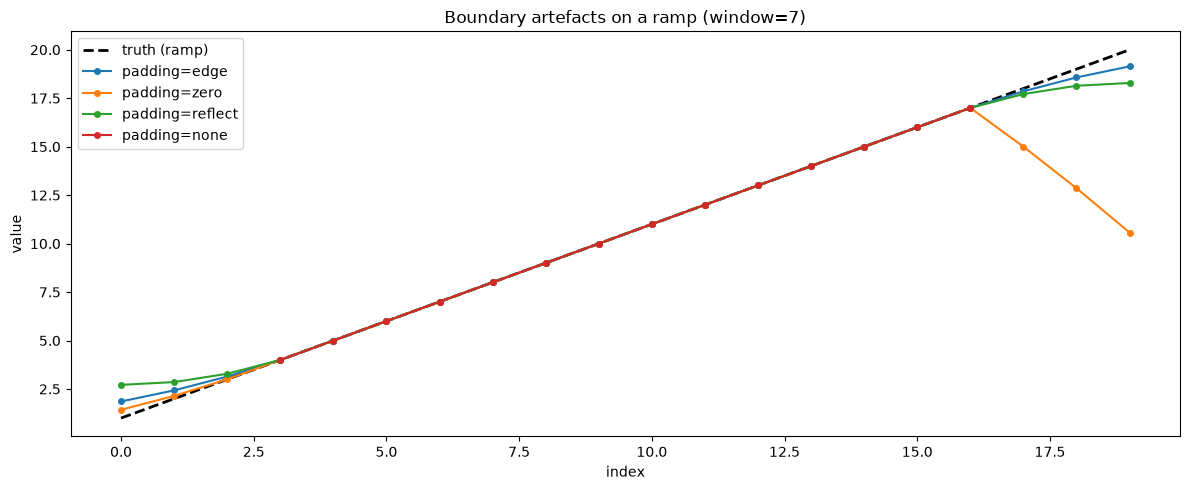

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
positions = list(range(len(ramp)))
ax.plot(positions, ramp, "k--", lw=2.0, label="truth (ramp)")
for index, strategy in enumerate(Padding):
    smoothed = mp.moving_average(ramp, ramp_window, padding=strategy)
    offset = (ramp_window - 1) // 2 if strategy is Padding.NONE else 0
    ax.plot(
        positions[offset : offset + len(smoothed)],
        smoothed,
        color=f"C{index}",
        marker="o",
        ms=4,
        lw=1.5,
        label=f"padding={strategy.value}",
    )
ax.set_xlabel("index")
ax.set_ylabel("value")
ax.set_title(f"Boundary artefacts on a ramp (window={ramp_window})")
ax.legend()
plt.tight_layout()
plt.show()

Quantifying the boundary error on the first and last `window // 2` samples, where padding is the only thing that differs:

In [13]:
edge = ramp_window // 2
print(f"{'padding':<10}{'edge RMSE':>12}{'interior RMSE':>16}")
print("-" * 38)
for strategy in Padding:
    if strategy is Padding.NONE:
        continue
    smoothed = mp.moving_average(ramp, ramp_window, padding=strategy)
    edge_values = smoothed[:edge] + smoothed[-edge:]
    edge_truth = ramp[:edge] + ramp[-edge:]
    interior = slice(edge, len(ramp) - edge)
    print(
        f"{strategy.value:<10}"
        f"{rmse(edge_values, edge_truth):>12.4f}"
        f"{rmse(smoothed[interior], ramp[interior]):>16.4f}"
    )

padding      edge RMSE   interior RMSE
--------------------------------------
edge            0.5594          0.0000
zero            4.7581          0.0000
reflect         1.1188          0.0000


The interior is identical for every strategy, as it must be — padding only ever affects the first and last `window // 2` samples. Reflect's edge error is exactly twice edge padding's here, which is the signature of slope reversal on a linear signal; reflect earns its keep on *oscillatory* ends, where repeating a single value is the worse lie. Zero padding is an order of magnitude worse than either and should be reserved for genuinely mean-zero signals.

When those end samples actually matter, the honest option is `Padding.NONE`: a shorter series beats invented data.

## Choosing a window

Sweeping the window length traces out the bias/variance trade directly. The variance term falls as $1/w$; the bias term grows with the curvature of the signal over the window. The minimum is where they cross.

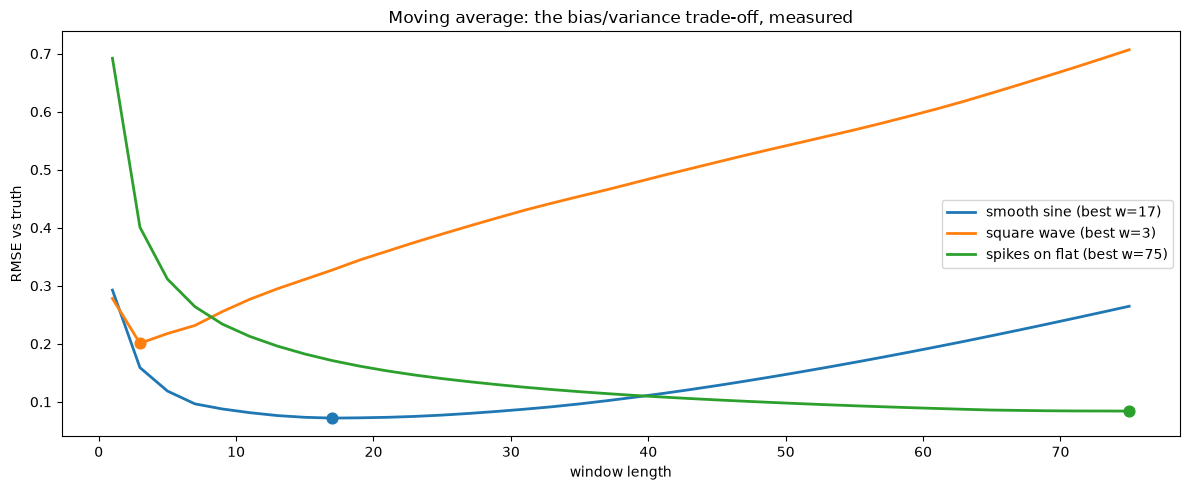

In [14]:
windows = list(range(1, 76, 2))
curves: dict[str, list[float]] = {}

for name, (truth, observed) in signals.items():
    curves[name] = [rmse(mp.moving_average(observed, w), truth) for w in windows]

fig, ax = plt.subplots(figsize=(12, 5))
for index, (name, errors) in enumerate(curves.items()):
    best = windows[errors.index(min(errors))]
    ax.plot(windows, errors, color=f"C{index}", lw=2.0, label=f"{name} (best w={best})")
    ax.scatter([best], [min(errors)], color=f"C{index}", zorder=5, s=60)
ax.set_xlabel("window length")
ax.set_ylabel("RMSE vs truth")
ax.set_title("Moving average: the bias/variance trade-off, measured")
ax.legend()
plt.tight_layout()
plt.show()

The smooth sine has a clear interior optimum around `w = 17`: wide enough to average away the noise, narrow enough not to flatten the peaks. The square wave bottoms out at the *narrowest* window tested, because every extra sample drags the filter further across a discontinuity — there is no width at which averaging helps a step edge.

The spike signal is the interesting one: its curve never turns around, it just keeps falling. A mean filter can only suppress an outlier by spreading it thinner over an ever-wider window, so the error decreases monotonically with width. That looks like a win here only because the truth is perfectly flat, so an arbitrarily wide window costs nothing. On any signal with real structure, the window needed to hide a spike would destroy the signal along with it — which is why the fix is a different filter, not a bigger number.

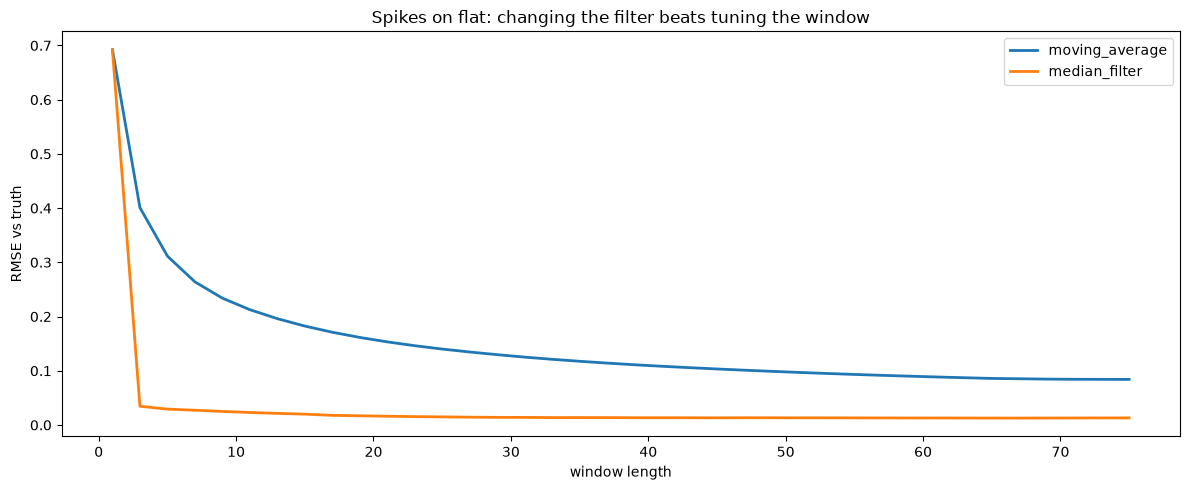

best mean-filter RMSE   : 0.0841
best median-filter RMSE : 0.0127


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
truth, observed = signals["spikes on flat"]
mean_curve = [rmse(mp.moving_average(observed, w), truth) for w in windows]
median_curve = [rmse(mp.median_filter(observed, w), truth) for w in windows]
ax.plot(windows, mean_curve, color="C0", lw=2.0, label="moving_average")
ax.plot(windows, median_curve, color="C1", lw=2.0, label="median_filter")
ax.set_xlabel("window length")
ax.set_ylabel("RMSE vs truth")
ax.set_title("Spikes on flat: changing the filter beats tuning the window")
ax.legend()
plt.tight_layout()
plt.show()

print(f"best mean-filter RMSE   : {min(mean_curve):.4f}")
print(f"best median-filter RMSE : {min(median_curve):.4f}")

## Reading the residual

In practice you do not have the truth, so you cannot plot those curves. What you *do* have is the residual, input minus output. If the filter is well chosen, the residual is structureless noise. If it has visible structure, the filter has eaten signal.

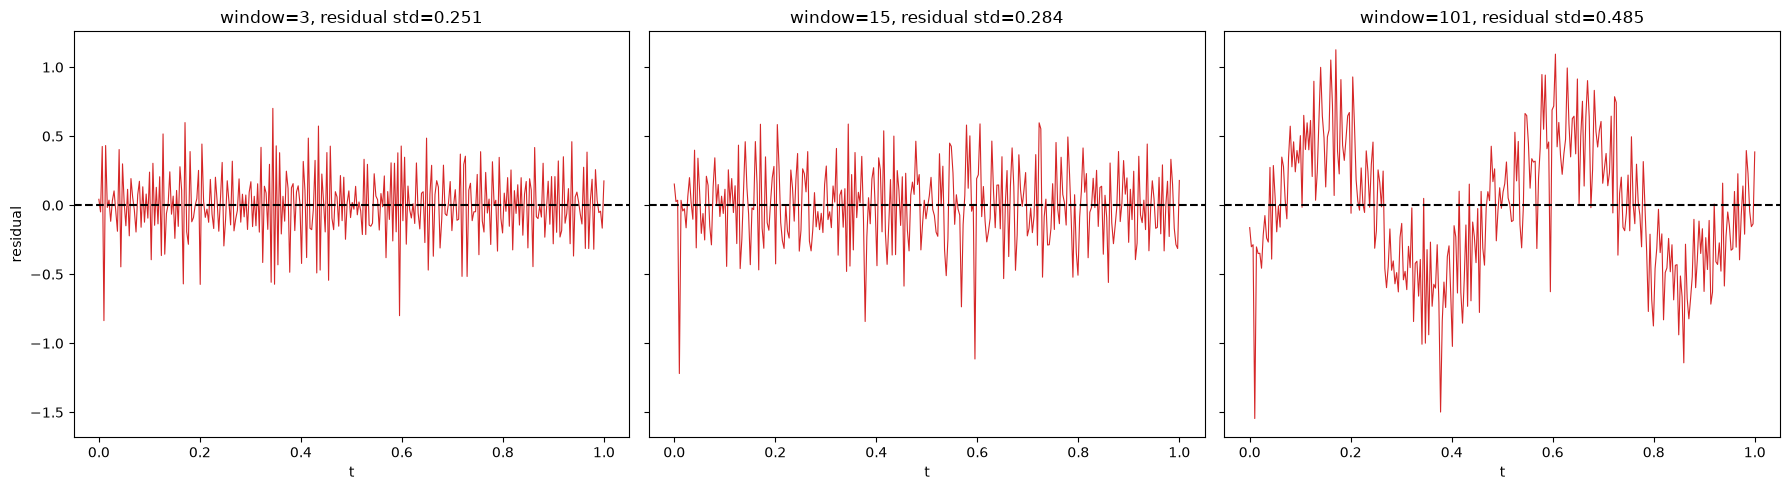

In [16]:
truth, observed = signals["smooth sine"]
candidates = [3, 15, 101]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, candidate in zip(axes, candidates, strict=True):
    smoothed = mp.moving_average(observed, candidate)
    residual = [a - b for a, b in zip(observed, smoothed, strict=True)]
    ax.plot(time, residual, color="C3", lw=0.8)
    ax.axhline(0.0, color="k", ls="--", lw=1.5)
    ax.set_xlabel("t")
    ax.set_title(f"window={candidate}, residual std={mp.summarize(residual).std:.3f}")
axes[0].set_ylabel("residual")
plt.tight_layout()
plt.show()

The residual you want has a standard deviation close to the true noise level $\sigma$ and no visible structure. At `window=3` it sits *below* $\sigma$ — the filter is passing a good part of the noise straight through to its output. At `window=15` it is close to $\sigma$. At `window=101` it is well above $\sigma$ and the sine is plainly visible in the plot: the filter is now removing signal, not noise.

A cheap numerical companion to the eyeball test is the lag-1 autocorrelation of the residual. It starts *negative*, because subtracting a local mean that includes the sample itself induces an anti-correlation, and it climbs as leaked signal starts to dominate. The crossing into positive territory is the warning sign.

In [17]:
def lag1_autocorrelation(values: list[float]) -> float:
    """Lag-1 autocorrelation — negative for a well-tuned filter's residual."""
    centred = mp.zscores(values)
    products = [a * b for a, b in itertools.pairwise(centred)]
    return mp.summarize(products, ddof=0).mean


print(f"{'window':>8}{'residual std':>15}{'lag-1 autocorr':>17}")
print("-" * 40)
for candidate in [3, 7, 15, 31, 61, 101]:
    smoothed = mp.moving_average(observed, candidate)
    residual = [a - b for a, b in zip(observed, smoothed, strict=True)]
    print(
        f"{candidate:>8}"
        f"{mp.summarize(residual).std:>15.4f}"
        f"{lag1_autocorrelation(residual):>17.4f}"
    )

print(f"\ntrue noise std: {sigma:.4f}")

  window   residual std   lag-1 autocorr
----------------------------------------
       3         0.2507          -0.6860
       7         0.2778          -0.2306
      15         0.2836          -0.1435
      31         0.2953          -0.0679
      61         0.3392           0.1940
     101         0.4852           0.6046

true noise std: 0.3000


Both diagnostics agree. The residual standard deviation crosses the true noise level of 0.30 and the lag-1 autocorrelation crosses zero between `window=31` and `window=61` — right where the measured RMSE curve says the optimum (`w = 17`) is long past. Two numbers you can compute without knowing the truth, pointing at the same conclusion as one you cannot.

## Summary

1. **The filter matters more than its parameter.** On spiky data no window length rescues a mean filter, while a median filter of almost any width works.
2. **The trade-off is measurable.** With a known truth, sweep the window and find the RMSE minimum; the variance term falls as $1/w$ while the bias term grows with signal curvature.
3. **Padding only touches the ends,** but it touches them a lot. `edge` assumes flatness, `reflect` reverses slope (exactly twice the edge error on a ramp) but preserves texture, and `zero` fabricates a trend unless the signal really is mean-zero. When the ends matter, `Padding.NONE` and a shorter series is the honest option.
4. **Without a truth, read the residual.** A residual standard deviation near the noise level with a still-negative lag-1 autocorrelation means a good fit; a residual above the noise level with positive autocorrelation means you are removing signal.

Everything above is computed with `mypackage` alone — NumPy only generates the test data.